In [21]:
!pip install tensorflow

Defaulting to user installation because normal site-packages is not writeable


In [22]:
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.optimizers import Adam
from keras.preprocessing import image
from PIL import Image
from tensorflow.keras import Input
from tensorflow.keras.callbacks import EarlyStopping, LearningRateScheduler
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.utils import Sequence
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.layers import TimeDistributed, LSTM, Reshape
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import BatchNormalization
from sklearn.metrics import accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Flatten, TimeDistributed, LSTM, GRU


In [23]:
# ========== ADD TO IMPORTS SECTION ==========
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns
# ========== END OF IMPORTS ==========

In [24]:
isl_train_path = r"D:\capstone\SIGN LANGUAGE\DATASETS\Indian\train"
isl_test_path = r"D:\capstone\SIGN LANGUAGE\DATASETS\Indian\test"
gsl_train_path = r"D:\capstone\SIGN LANGUAGE\DATASETS\gsl\TRAINING"
gsl_test_path = r"D:\capstone\SIGN LANGUAGE\DATASETS\gsl\TESTING"
asl_train_path = r"D:\capstone\SIGN LANGUAGE\DATASETS\asl_dataset\Train"
asl_test_path = r"D:\capstone\SIGN LANGUAGE\DATASETS\asl_dataset\Test"

In [25]:
# ========== ADD PLOTTING FUNCTIONS HERE ==========
def plot_history(history, title):
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(f'{title} - Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'{title} - Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.tight_layout()
    plt.show()


In [26]:
def plot_f1_scores(y_true, y_pred, class_names, title):
    report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
    
    # Extract F1 scores for each class (using class names as keys)
    f1_scores = []
    for name in class_names:
        f1_scores.append(report[name]['f1-score'])
    
    plt.figure(figsize=(10, 6))
    plt.bar(range(len(class_names)), f1_scores)
    plt.xticks(range(len(class_names)), class_names, rotation=45)
    plt.title(f'{title} - F1 Scores per Class')
    plt.xlabel('Class')
    plt.ylabel('F1 Score')
    plt.ylim(0, 1.1)
    plt.tight_layout()
    plt.show()

In [27]:
def plot_confusion_matrix(y_true, y_pred, class_names, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'{title} - Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

In [28]:
def create_model(num_classes):
    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=(64, 64, 3)),
        MaxPooling2D(pool_size=(2, 2)),
        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D(pool_size=(2, 2)),
        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(64, activation='relu'),
        Dense(num_classes, activation='softmax')  # 26 classes for alphabets
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

datagen = ImageDataGenerator(rescale=1./255)

In [29]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import numpy as np
import seaborn as sns


In [30]:
# Load train and test data with augmentation
train_data_isl = datagen.flow_from_directory(isl_train_path, target_size=(224, 224), batch_size=32, class_mode='categorical')
test_data_isl = datagen.flow_from_directory(isl_test_path, target_size=(224, 224), batch_size=32, class_mode='categorical')

# Create a learning rate scheduler
def lr_schedule(epoch, lr):
    if epoch > 5:
        return lr * 0.5
    return lr

lr_scheduler = LearningRateScheduler(lr_schedule)

# Early stopping to prevent overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Transfer learning with MobileNetV2
def create_model(num_classes):
    base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    base_model.trainable = False  # Freeze base model layers

    model = Sequential([
        base_model,
        Flatten(),
        Dense(256, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),  # Regularization
        Dense(num_classes, activation='softmax')
    ])
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model, base_model

# Create and train ISL model
isl_model, _ = create_model(train_data_isl.num_classes)

# Train the model
history = isl_model.fit(train_data_isl, epochs=15, validation_data=test_data_isl, callbacks=[early_stopping, lr_scheduler])

# Save the model
isl_model.save('ISL.keras')

Found 45500 images belonging to 26 classes.
Found 9750 images belonging to 26 classes.
Epoch 1/15


C:\Users\beraa\AppData\Roaming\Python\Python312\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1422/1422 ━━━━━━━━━━━━━━━━━━━━ 556s 389ms/step - accuracy: 0.8135 - loss: 0.7062 - val_accuracy: 0.9598 - val_loss: 0.1348 - learning_rate: 0.0010
Epoch 2/15
1422/1422 ━━━━━━━━━━━━━━━━━━━━ 551s 388ms/step - accuracy: 0.9690 - loss: 0.1130 - val_accuracy: 0.9667 - val_loss: 0.1119 - learning_rate: 0.0010
Epoch 3/15
1422/1422 ━━━━━━━━━━━━━━━━━━━━ 542s 381ms/step - accuracy: 0.9789 - loss: 0.0704 - val_accuracy: 0.9752 - val_loss: 0.0958 - learning_rate: 0.0010
Epoch 4/15
1422/1422 ━━━━━━━━━━━━━━━━━━━━ 575s 404ms/step - accuracy: 0.9835 - loss: 0.0563 - val_accuracy: 0.9717 - val_loss: 0.0964 - learning_rate: 0.0010
Epoch 5/15
1422/1422 ━━━━━━━━━━━━━━━━━━━━ 569s 400ms/step - accuracy: 0.9855 - loss: 0.0465 - val_accuracy: 0.9767 - val_loss: 0.0904 - learning_rate: 0.0010
Epoch 6/15
1422/1422 ━━━━━━━━━━━━━━━━━━━━ 567s 399ms/step - accuracy: 0.9878 - loss: 0.0384 - val_accuracy: 0.9797 - val_loss: 0.0782 - learning_rate: 0.0010
Epoch 7/15
1422/1422 ━━━━━━━━━━━━━━━━━━━━ 559s 393ms/step - acc

305/305 ━━━━━━━━━━━━━━━━━━━━ 89s 288ms/step


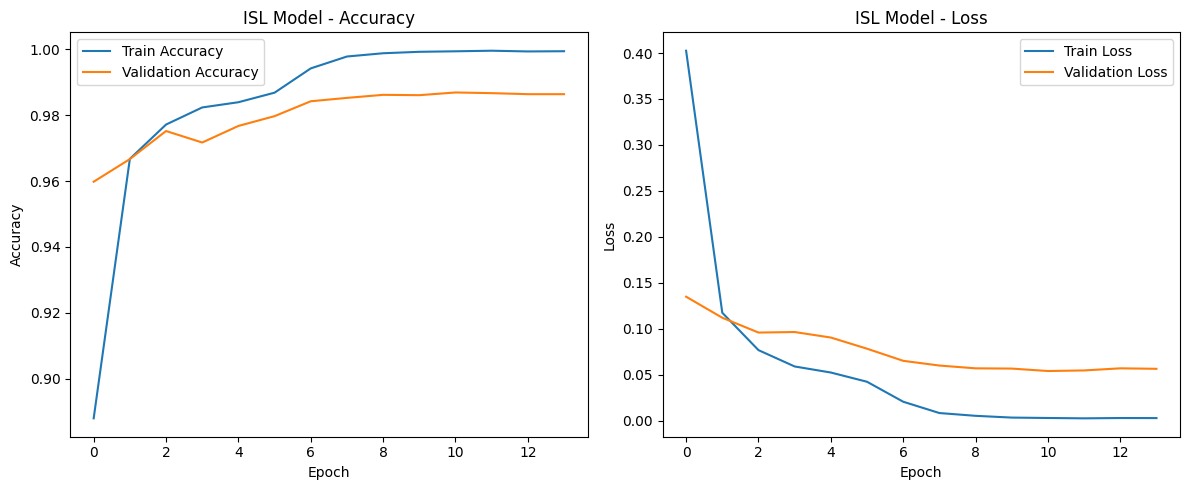

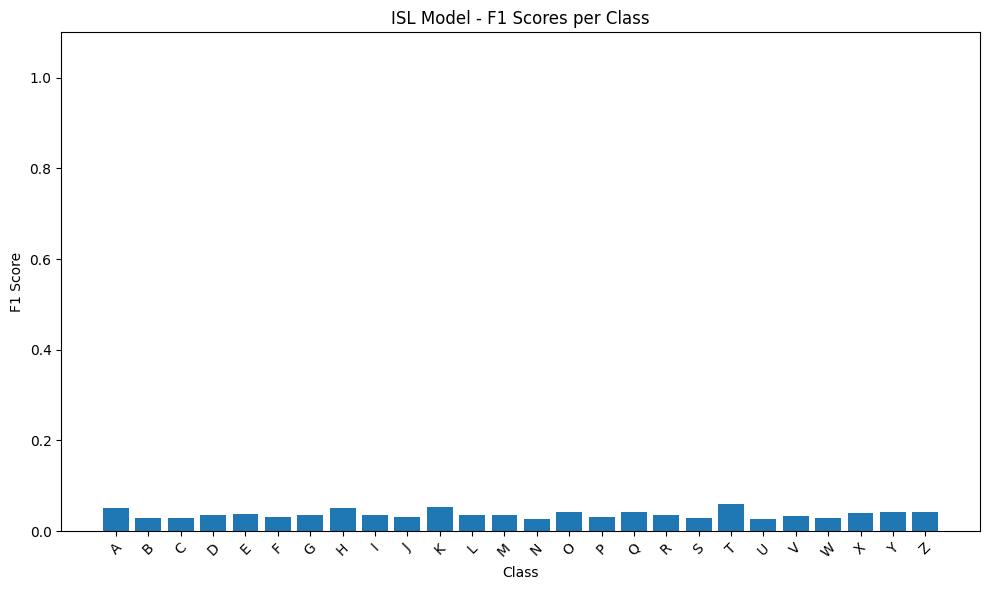

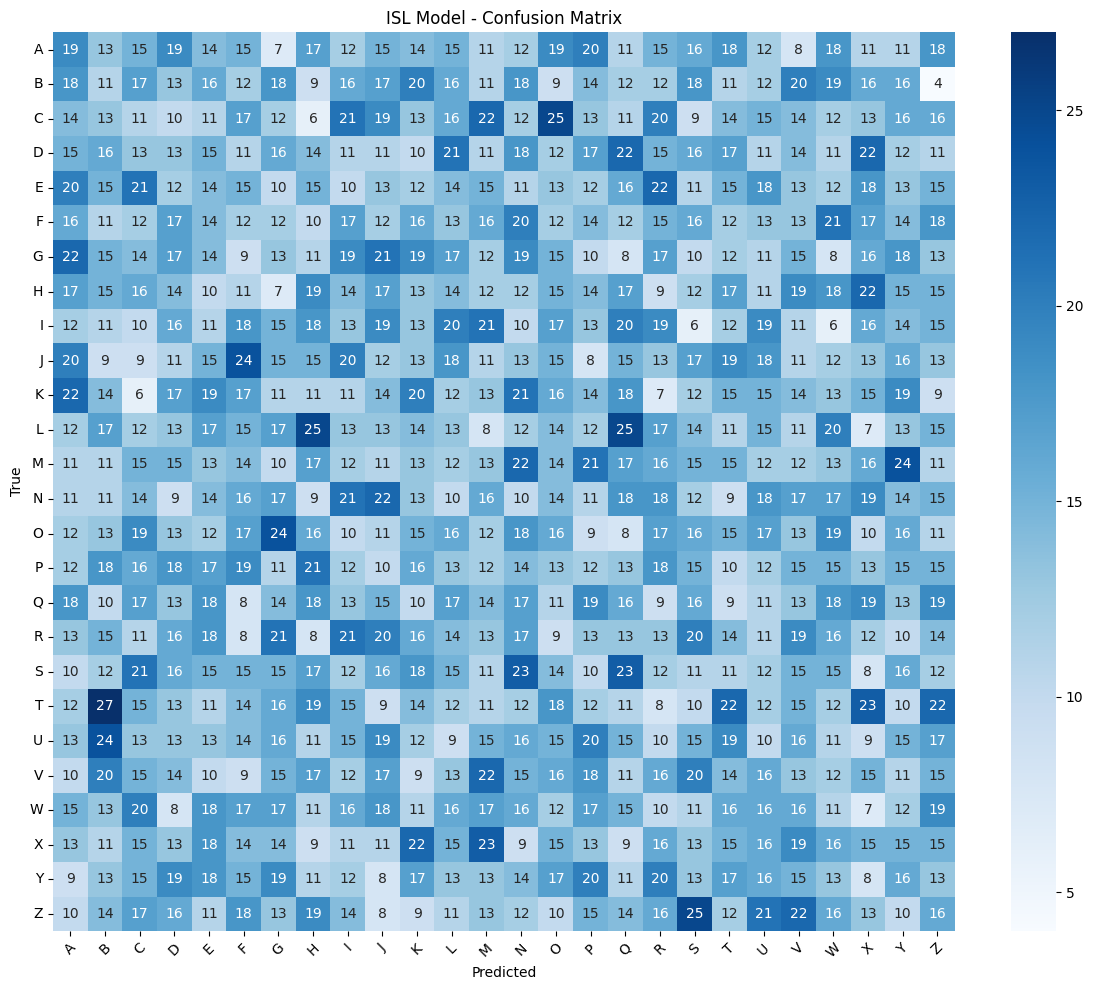

In [ ]:

y_pred_isl = np.argmax(isl_model.predict(test_data_isl), axis=1)
y_test_isl = test_data_isl.classes
class_names_isl = list(test_data_isl.class_indices.keys())

# Plot evaluation metrics
plot_history(history, "ISL Model")
plot_f1_scores(y_test_isl, y_pred_isl, class_names_isl, "ISL Model")
plot_confusion_matrix(y_test_isl, y_pred_isl, class_names_isl, "ISL Model")


In [37]:
# Load train and test data with augmentation
train_data_gsl = datagen.flow_from_directory(gsl_train_path, target_size=(224, 224), batch_size=32, class_mode='categorical')
test_data_gsl = datagen.flow_from_directory(gsl_test_path, target_size=(224, 224), batch_size=32, class_mode='categorical')

# Create a learning rate scheduler
def lr_schedule(epoch, lr):
    if epoch > 5:
        return lr * 0.5
    return lr

lr_scheduler = LearningRateScheduler(lr_schedule)

# Early stopping to prevent overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Transfer learning with MobileNetV2
def create_model(num_classes):
    base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    base_model.trainable = False  # Freeze base model layers

    model = Sequential([
        base_model,
        Flatten(),
        Dense(256, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),  # Regularization
        Dense(num_classes, activation='softmax')
    ])
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model, base_model

# Create and train ISL model
gsl_model, _ = create_model(train_data_gsl.num_classes)

# Train the model
history = gsl_model.fit(train_data_gsl, epochs=15, validation_data=test_data_gsl, callbacks=[early_stopping, lr_scheduler])

# Save the model
gsl_model.save('GSL.keras')

Found 3868 images belonging to 26 classes.
Found 1300 images belonging to 26 classes.


C:\Users\beraa\AppData\Roaming\Python\Python312\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
121/121 ━━━━━━━━━━━━━━━━━━━━ 60s 471ms/step - accuracy: 0.7124 - loss: 1.2376 - val_accuracy: 0.4708 - val_loss: 1.8876 - learning_rate: 0.0010
Epoch 2/15
121/121 ━━━━━━━━━━━━━━━━━━━━ 67s 550ms/step - accuracy: 0.9878 - loss: 0.0654 - val_accuracy: 0.4531 - val_loss: 1.7891 - learning_rate: 0.0010
Epoch 3/15
121/121 ━━━━━━━━━━━━━━━━━━━━ 57s 469ms/step - accuracy: 0.9971 - loss: 0.0241 - val_accuracy: 0.4738 - val_loss: 1.6954 - learning_rate: 0.0010
Epoch 4/15
121/121 ━━━━━━━━━━━━━━━━━━━━ 54s 446ms/step - accuracy: 0.9996 - loss: 0.0091 - val_accuracy: 0.4738 - val_loss: 1.7335 - learning_rate: 0.0010
Epoch 5/15
121/121 ━━━━━━━━━━━━━━━━━━━━ 56s 465ms/step - accuracy: 0.9986 - loss: 0.0080 - val_accuracy: 0.4931 - val_loss: 1.6620 - learning_rate: 0.0010
Epoch 6/15
121/121 ━━━━━━━━━━━━━━━━━━━━ 65s 533ms/step - accuracy: 1.0000 - loss: 0.0051 - val_accuracy: 0.4900 - val_loss: 1.6708 - learning_rate: 0.0010
Epoch 7/15
121/121 ━━━━━━━━━━━━━━━━━━━━ 65s 533ms/step - accuracy: 0.9

41/41 ━━━━━━━━━━━━━━━━━━━━ 12s 271ms/step


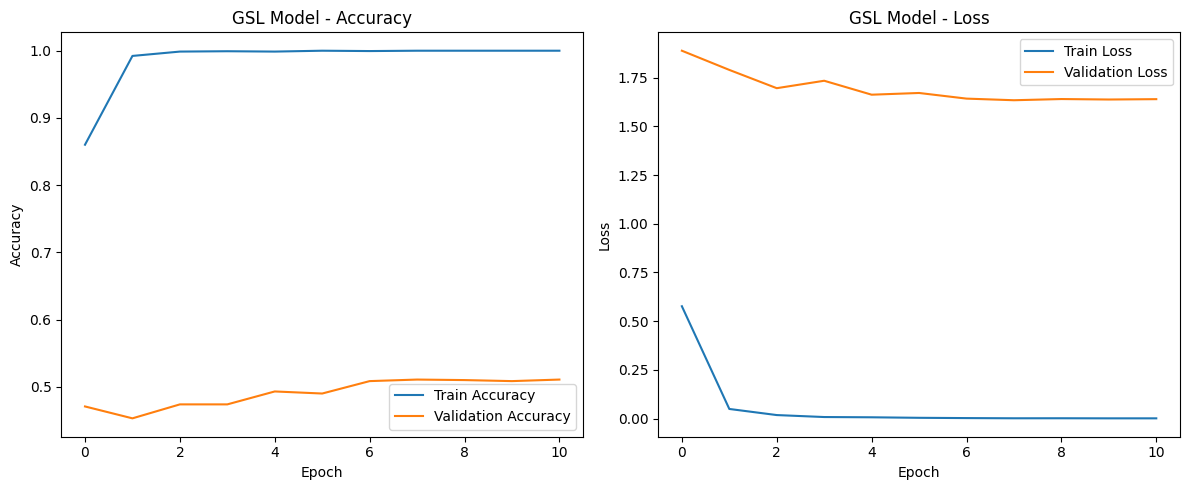

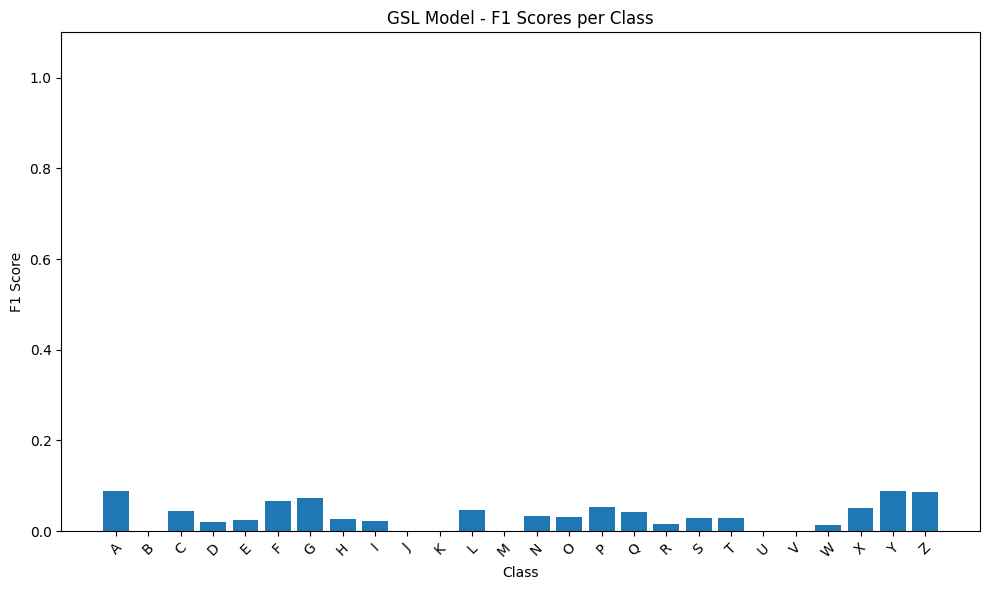

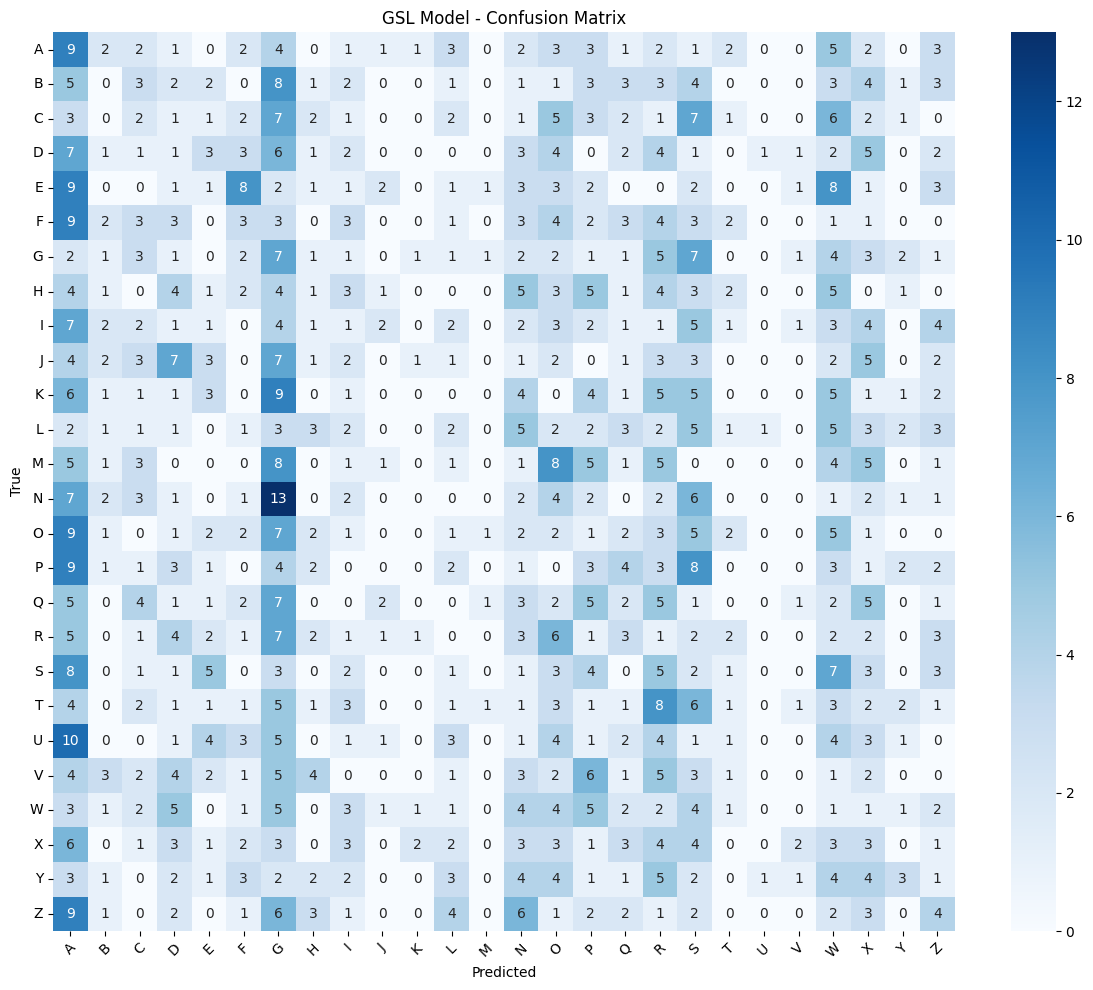

In [38]:
# ========== INSERT THIS RIGHT AFTER GSL MODEL TRAINING ==========
# Get predictions and true labels
y_pred_gsl = np.argmax(gsl_model.predict(test_data_gsl), axis=1)
y_test_gsl = test_data_gsl.classes
class_names_gsl = list(test_data_gsl.class_indices.keys())

# Plot evaluation metrics
plot_history(history, "GSL Model")
plot_f1_scores(y_test_gsl, y_pred_gsl, class_names_gsl, "GSL Model")
plot_confusion_matrix(y_test_gsl, y_pred_gsl, class_names_gsl, "GSL Model")
# ========== END OF INSERTION ==========

In [40]:
# Load train and test data with augmentation
train_data_asl = datagen.flow_from_directory(asl_train_path, target_size=(224, 224), batch_size=32, class_mode='categorical')
test_data_asl = datagen.flow_from_directory(asl_test_path, target_size=(224, 224), batch_size=32, class_mode='categorical')

# Create a learning rate scheduler
def lr_schedule(epoch, lr):
    if epoch > 5:
        return lr * 0.5
    return lr

lr_scheduler = LearningRateScheduler(lr_schedule)

# Early stopping to prevent overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Transfer learning with MobileNetV2
def create_model(num_classes):
    base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    base_model.trainable = False  # Freeze base model layers

    model = Sequential([
        base_model,
        Flatten(),
        Dense(256, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),  # Regularization
        Dense(num_classes, activation='softmax')
    ])
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model, base_model

# Create and train ISL model
asl_model, _ = create_model(train_data_asl.num_classes)

# Train the model
history = asl_model.fit(train_data_asl, epochs=15, validation_data=test_data_asl, callbacks=[early_stopping, lr_scheduler])

# Save the model
asl_model.save('ASL.keras')

Found 151188 images belonging to 26 classes.
Found 2704 images belonging to 26 classes.
Epoch 1/15
4725/4725 ━━━━━━━━━━━━━━━━━━━━ 1545s 326ms/step - accuracy: 0.9842 - loss: 0.0679 - val_accuracy: 0.9978 - val_loss: 0.0084 - learning_rate: 0.0010
Epoch 2/15
4725/4725 ━━━━━━━━━━━━━━━━━━━━ 1513s 320ms/step - accuracy: 0.9991 - loss: 0.0037 - val_accuracy: 0.9985 - val_loss: 0.0057 - learning_rate: 0.0010
Epoch 3/15
4725/4725 ━━━━━━━━━━━━━━━━━━━━ 1519s 321ms/step - accuracy: 0.9993 - loss: 0.0022 - val_accuracy: 0.9996 - val_loss: 0.0022 - learning_rate: 0.0010
Epoch 4/15
4725/4725 ━━━━━━━━━━━━━━━━━━━━ 1539s 326ms/step - accuracy: 0.9997 - loss: 0.0010 - val_accuracy: 0.9996 - val_loss: 0.0027 - learning_rate: 0.0010
Epoch 5/15
4725/4725 ━━━━━━━━━━━━━━━━━━━━ 1637s 346ms/step - accuracy: 0.9998 - loss: 6.4712e-04 - val_accuracy: 0.9945 - val_loss: 0.0379 - learning_rate: 0.0010
Epoch 6/15
4725/4725 ━━━━━━━━━━━━━━━━━━━━ 1711s 362ms/step - accuracy: 0.9998 - loss: 5.8317e-04 - val_accuracy: 

85/85 ━━━━━━━━━━━━━━━━━━━━ 23s 263ms/step


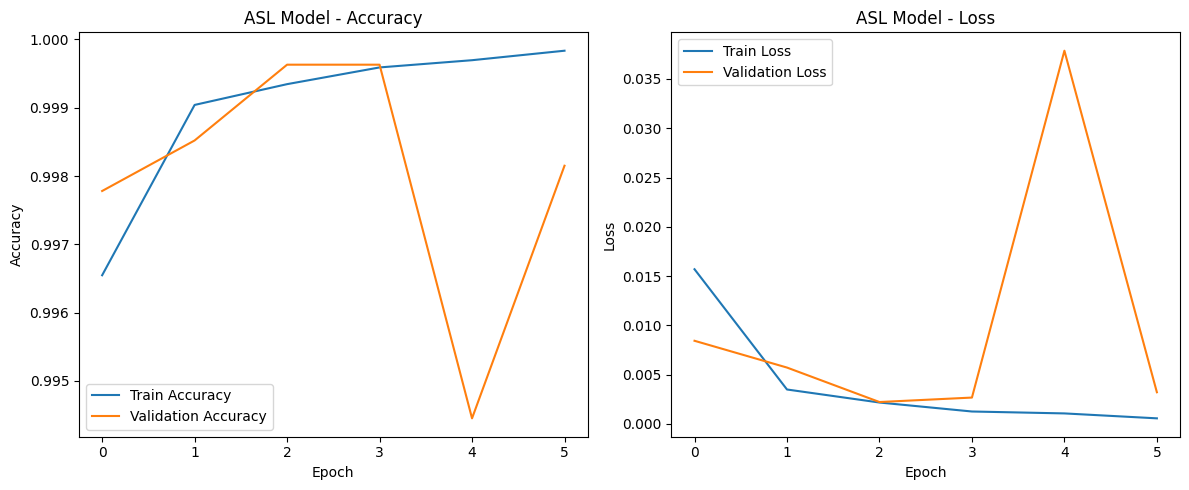

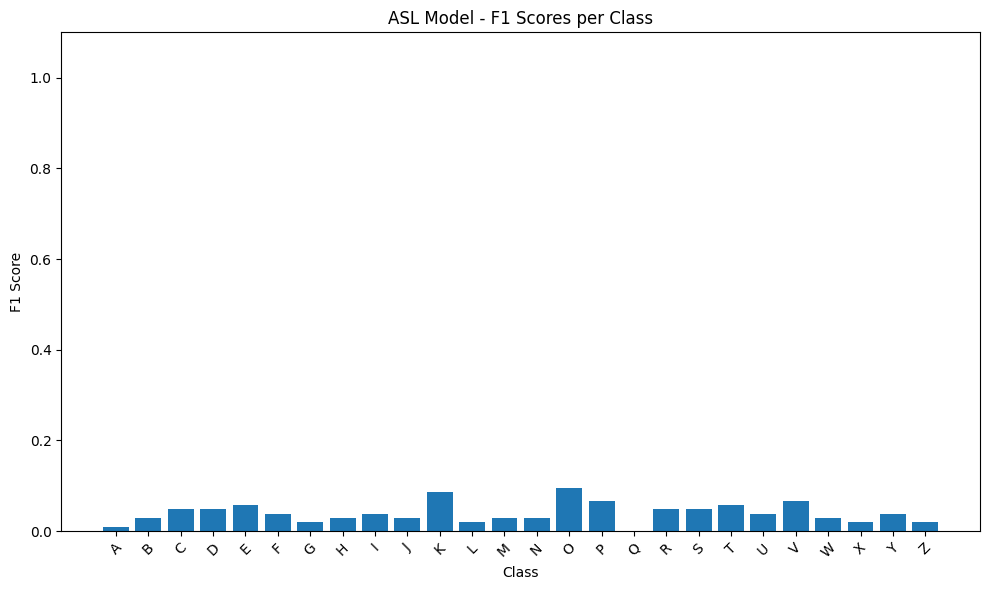

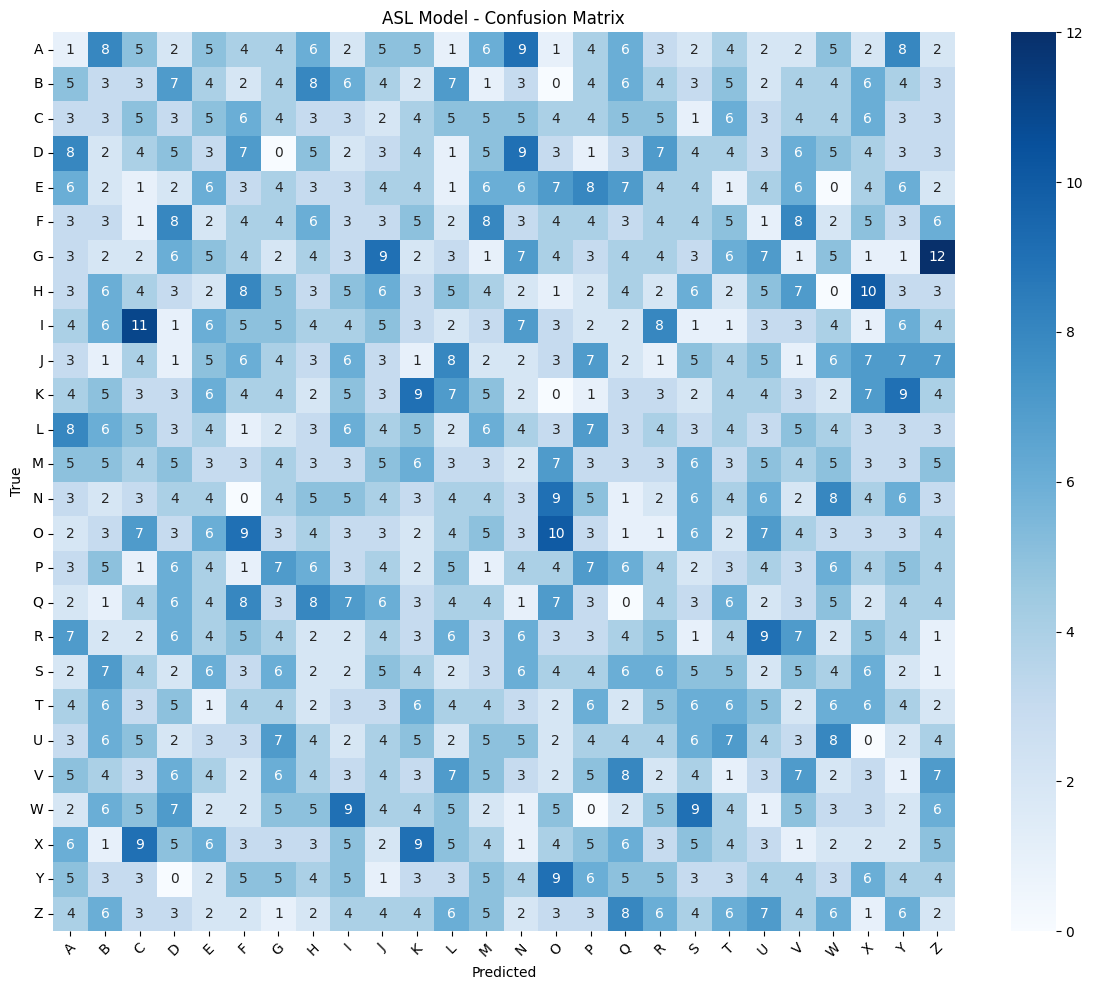

In [41]:
# ========== INSERT THIS RIGHT AFTER ASL MODEL TRAINING ==========
# Get predictions and true labels
y_pred_asl = np.argmax(asl_model.predict(test_data_asl), axis=1)
y_test_asl = test_data_asl.classes
class_names_asl = list(test_data_asl.class_indices.keys())

# Plot evaluation metrics
plot_history(history, "ASL Model")
plot_f1_scores(y_test_asl, y_pred_asl, class_names_asl, "ASL Model")
plot_confusion_matrix(y_test_asl, y_pred_asl, class_names_asl, "ASL Model")
# ========== END OF INSERTION ==========